# MorphPT H&E → expression — main figure (random split, top-200)

Four-panel descriptive figure for the regression contribution. MorphPT only (allblocks LoRA), random 70/15/15 cell-level split, top-100 variance-ranked genes per tissue.

- **A.** Mean test Pearson r across 4 tissues
- **B.** Performance-ranked tier curve (top-100), 4 tissues on one axis
- **C.** Observed vs predicted spatial maps + scatter for 2 brain + 2 embryo genes (uses `test_y_pred_seed_X.npy`, `test_y_true_seed_X.npy`, `splits_seed_X.npz`, plus cache `meta.csv`)
- **D.** 2x2 grid: variance-ranked, coverage-ranked, performance-ranked tier curves per tissue

Currently single-seed (42). Multi-seed plugs in by extending `SEEDS`.

In [1]:
# =============================================================================
# Dataset / split / top-100 gene summary for H&E-to-expression downstream task
# =============================================================================

from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
PROJECT_ROOT = Path("/hpc/group/jilab/tc459/MorphPT")

TISSUES = ["mouse_brain", "mouse_intestine", "mouse_kidney", "mouse_embryo"]

TISSUE_LABELS = {
    "mouse_brain": "Brain",
    "mouse_intestine": "Intestine",
    "mouse_kidney": "Kidney",
    "mouse_embryo": "Embryo",
}

SPLIT_LAYOUT = "default"
SPLIT_MODE = "random"
TOP_K = 100
MIN_COVERAGE = 0.10

# Update this if you used multiple random seeds.
# If df already exists and has a seed column, this will be overwritten below.
SEEDS = [42]

# Training protocol used for the main downstream random-split run.
TRAINING_CONFIG = {
    "patch_modality": "H&E",
    "patch_scale": "10.0x",
    "image_size": "224 x 224",
    "target_genes": TOP_K,
    "gene_selection": f"top-{TOP_K} variance-ranked genes after {MIN_COVERAGE:.0%} coverage filtering",
    "split_mode": SPLIT_MODE,
    "split_layout": SPLIT_LAYOUT,
    "loss": "MSE on z-score normalized expression",
    "backbone": "MorphPT pretrained DINOv3 ViT-B/16 visual backbone",
    "lora_blocks": "0, 2, 4, 6, 8, 10, 11",
    "lora_targets": "qkv, proj, mlp_fc1, mlp_fc2",
    "regression_head": "MLP, hidden dim 1024, 500/200/100 output depending on target set",
    "batch_size": 256,
    "optimizer": "AdamW",
}

if "df" in globals() and isinstance(df, pd.DataFrame) and "seed" in df.columns:
    SEEDS = sorted(pd.to_numeric(df["seed"], errors="coerce").dropna().astype(int).unique().tolist())

print("Using seeds:", SEEDS)


# ---------------------------------------------------------------------
# Generic file readers
# ---------------------------------------------------------------------
def read_table(path: Path) -> pd.DataFrame:
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in [".tsv", ".txt"]:
        return pd.read_csv(path, sep="\t")
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix in [".pkl", ".pickle"]:
        return pd.read_pickle(path)

    raise ValueError(f"Unsupported table type: {path}")


def normalize_cols(d):
    d = d.copy()
    d.columns = [str(c).strip().lower().replace(" ", "_").replace("-", "_") for c in d.columns]
    return d


def safe_len_table(path: Path):
    try:
        return len(read_table(path))
    except Exception:
        return np.nan


def cache_dir(tissue):
    return PROJECT_ROOT / f"cache_{tissue}"


# ---------------------------------------------------------------------
# Find cell metadata / coordinate files
# ---------------------------------------------------------------------
def find_cell_metadata_file(tissue):
    cdir = cache_dir(tissue)
    if not cdir.exists():
        return None

    candidates = []
    patterns = [
        "*cell*.csv", "*cells*.csv", "*obs*.csv", "*metadata*.csv",
        "*coord*.csv", "*centroid*.csv",
        "*cell*.parquet", "*obs*.parquet", "*metadata*.parquet",
    ]

    for pat in patterns:
        candidates.extend(cdir.rglob(pat))

    # avoid gene-ranking and result files
    candidates = [
        p for p in candidates
        if "splits" not in str(p)
        and "top" not in p.name.lower()
        and "result" not in p.name.lower()
    ]

    scored = []
    for p in candidates:
        try:
            tmp = read_table(p)
            cols = {str(c).lower() for c in tmp.columns}
            coord_score = int(any(c in cols for c in ["x", "y", "center_x", "center_y", "pxl_col_in_fullres", "pxl_row_in_fullres"]))
            scored.append((coord_score, len(tmp), p))
        except Exception:
            pass

    if not scored:
        return None

    scored = sorted(scored, key=lambda x: (x[0], x[1]), reverse=True)
    return scored[0][2]


def infer_total_cells(tissue):
    meta_file = find_cell_metadata_file(tissue)

    if meta_file is not None:
        try:
            return len(read_table(meta_file)), str(meta_file)
        except Exception:
            pass

    cdir = cache_dir(tissue)
    if not cdir.exists():
        return np.nan, None

    # fallback to common coordinate arrays
    array_candidates = []
    for pat in ["*coord*.npy", "*coords*.npy", "*centroid*.npy", "*xy*.npy"]:
        array_candidates.extend(cdir.rglob(pat))

    for p in array_candidates:
        try:
            arr = np.load(p, mmap_mode="r")
            if arr.ndim >= 1:
                return int(arr.shape[0]), str(p)
        except Exception:
            pass

    return np.nan, None


# ---------------------------------------------------------------------
# Split summary
# ---------------------------------------------------------------------
def find_split_tables(tissue, layout=SPLIT_LAYOUT, seed=None):
    sdir = cache_dir(tissue) / "splits" / layout
    if not sdir.exists():
        return []

    tables = []
    for pat in ["*.csv", "*.tsv", "*.parquet", "*.pkl", "*.pickle"]:
        tables.extend(sdir.glob(pat))

    if seed is not None:
        seed_str = str(seed)
        seed_tables = [p for p in tables if seed_str in p.name]
        # keep non-seed files too, because default split files often omit seed
        tables = seed_tables + [p for p in tables if "seed" not in p.name.lower()]

    return sorted(set(tables))


def infer_split_counts_from_tables(tissue, layout=SPLIT_LAYOUT, seed=None):
    tables = find_split_tables(tissue, layout=layout, seed=seed)
    records = []

    # Case 1: one assignment table with a split column
    for p in tables:
        try:
            d = normalize_cols(read_table(p))
        except Exception:
            continue

        split_cols = [c for c in d.columns if c in ["split", "split_name", "set", "subset", "partition"]]
        if split_cols:
            split_col = split_cols[0]
            vc = d[split_col].astype(str).str.lower().value_counts()
            if any(k in vc.index for k in ["train", "val", "valid", "validation", "test"]):
                return {
                    "train_cells": int(vc.get("train", 0)),
                    "val_cells": int(vc.get("val", 0) + vc.get("valid", 0) + vc.get("validation", 0)),
                    "test_cells": int(vc.get("test", 0)),
                    "split_source": str(p),
                }

    # Case 2: separate train/val/test files
    counts = {"train_cells": np.nan, "val_cells": np.nan, "test_cells": np.nan}
    source_parts = []

    for split_name, aliases in {
        "train_cells": ["train"],
        "val_cells": ["val", "valid", "validation"],
        "test_cells": ["test"],
    }.items():
        hits = []
        for p in tables:
            name = p.name.lower()
            if any(a in name for a in aliases):
                # avoid top gene csvs
                if "top" not in name and "gene" not in name:
                    hits.append(p)

        if hits:
            # choose largest file if multiple
            sizes = [(safe_len_table(p), p) for p in hits]
            sizes = sorted(sizes, key=lambda x: x[0], reverse=True)
            counts[split_name] = int(sizes[0][0])
            source_parts.append(str(sizes[0][1]))

    if not all(pd.isna(v) for v in counts.values()):
        counts["split_source"] = "; ".join(source_parts)
        return counts

    return {
        "train_cells": np.nan,
        "val_cells": np.nan,
        "test_cells": np.nan,
        "split_source": None,
    }


# ---------------------------------------------------------------------
# Top gene CSV
# ---------------------------------------------------------------------
def find_top_gene_csv(tissue, seed=42, top_k=TOP_K, layout=SPLIT_LAYOUT):
    sdir = cache_dir(tissue) / "splits" / layout
    if not sdir.exists():
        return None

    exact_patterns = [
        f"top{top_k}_variance_mincov*_train_{layout}_seed{seed}.csv",
        f"top{top_k}_variance*_seed{seed}.csv",
        f"top{top_k}_*.csv",
    ]

    for pat in exact_patterns:
        hits = sorted(sdir.glob(pat))
        if hits:
            return hits[0]

    # fallback: use a larger top-N file and take rank <= top_k
    fallback = sorted(sdir.glob(f"top*_variance*.csv"))
    if fallback:
        # prefer same seed
        same_seed = [p for p in fallback if str(seed) in p.name]
        return same_seed[0] if same_seed else fallback[0]

    return None


def read_top_genes(tissue, seed=42, top_k=TOP_K):
    p = find_top_gene_csv(tissue, seed=seed, top_k=top_k)

    if p is None:
        return pd.DataFrame(), None

    d = normalize_cols(pd.read_csv(p))

    if "gene_name" not in d.columns:
        # common fallbacks
        for c in ["gene", "symbol", "target_gene", "name"]:
            if c in d.columns:
                d = d.rename(columns={c: "gene_name"})
                break

    if "gene_name" not in d.columns:
        raise ValueError(f"Could not find gene column in {p}. Columns: {list(d.columns)}")

    if "rank" in d.columns:
        d = d.sort_values("rank").head(top_k)
    else:
        d = d.head(top_k)
        d["rank"] = np.arange(1, len(d) + 1)

    d["tissue"] = tissue
    d["seed"] = seed
    d["top_csv"] = str(p)
    d["top_k_used"] = top_k

    return d, p


# ---------------------------------------------------------------------
# Build dataset summary tables
# ---------------------------------------------------------------------
dataset_rows = []
top_gene_frames = []

for tissue in TISSUES:
    total_cells, cell_source = infer_total_cells(tissue)

    for seed in SEEDS:
        split_counts = infer_split_counts_from_tables(tissue, layout=SPLIT_LAYOUT, seed=seed)
        top_genes, top_path = read_top_genes(tissue, seed=seed, top_k=TOP_K)

        if not top_genes.empty:
            top_gene_frames.append(top_genes)

        row = {
            "tissue": tissue,
            "tissue_label": TISSUE_LABELS.get(tissue, tissue),
            "seed": seed,
            "split_mode": SPLIT_MODE,
            "split_layout": SPLIT_LAYOUT,
            "total_cells_detected": total_cells,
            "train_cells": split_counts.get("train_cells", np.nan),
            "val_cells": split_counts.get("val_cells", np.nan),
            "test_cells": split_counts.get("test_cells", np.nan),
            "n_target_genes": len(top_genes),
            "top_gene_csv": str(top_path) if top_path else None,
            "cell_metadata_source": cell_source,
            "split_source": split_counts.get("split_source", None),
        }

        # Gene-selection stats when columns exist
        for col in ["coverage", "variance", "mean", "std"]:
            if col in top_genes.columns:
                row[f"target_{col}_mean"] = pd.to_numeric(top_genes[col], errors="coerce").mean()
                row[f"target_{col}_min"] = pd.to_numeric(top_genes[col], errors="coerce").min()
                row[f"target_{col}_max"] = pd.to_numeric(top_genes[col], errors="coerce").max()

        dataset_rows.append(row)

dataset_summary = pd.DataFrame(dataset_rows)

if top_gene_frames:
    top_gene_table = pd.concat(top_gene_frames, ignore_index=True)
else:
    top_gene_table = pd.DataFrame()

display(Markdown("### Dataset and split summary"))
display(dataset_summary)

display(Markdown("### Top-100 target gene table"))
display(top_gene_table.head(20))


# ---------------------------------------------------------------------
# Performance summary from df, if available
# ---------------------------------------------------------------------
performance_summary = None
gene_performance_top100 = None

if "df" in globals() and isinstance(df, pd.DataFrame):
    required = {"tissue", "gene_name", "test_pearson"}
    if required.issubset(set(df.columns)):
        perf = df.copy()
        perf["test_pearson"] = pd.to_numeric(perf["test_pearson"], errors="coerce")

        # If df has rank, use rank <= TOP_K.
        # Otherwise, merge to top_gene_table.
        if "rank" in perf.columns:
            gene_performance_top100 = perf[pd.to_numeric(perf["rank"], errors="coerce") <= TOP_K].copy()
        elif not top_gene_table.empty:
            gene_performance_top100 = perf.merge(
                top_gene_table[["tissue", "seed", "gene_name"]].drop_duplicates()
                if "seed" in perf.columns and "seed" in top_gene_table.columns
                else top_gene_table[["tissue", "gene_name"]].drop_duplicates(),
                on=["tissue", "seed", "gene_name"] if "seed" in perf.columns and "seed" in top_gene_table.columns else ["tissue", "gene_name"],
                how="inner",
            )
        else:
            gene_performance_top100 = perf.copy()

        group_cols = ["tissue"]
        if "seed" in gene_performance_top100.columns:
            group_cols.append("seed")

        performance_by_seed = (
            gene_performance_top100
            .dropna(subset=["test_pearson"])
            .groupby(group_cols, as_index=False)
            .agg(
                n_genes=("gene_name", "nunique"),
                mean_test_r=("test_pearson", "mean"),
                median_test_r=("test_pearson", "median"),
                q25_test_r=("test_pearson", lambda x: np.percentile(x, 25)),
                q75_test_r=("test_pearson", lambda x: np.percentile(x, 75)),
                max_test_r=("test_pearson", "max"),
            )
        )

        performance_summary = (
            performance_by_seed
            .groupby("tissue", as_index=False)
            .agg(
                n_runs=("mean_test_r", "count"),
                n_genes=("n_genes", "max"),
                mean_test_r=("mean_test_r", "mean"),
                std_test_r=("mean_test_r", lambda x: x.std(ddof=1) if len(x) > 1 else np.nan),
                median_gene_r=("median_test_r", "mean"),
                best_gene_r=("max_test_r", "mean"),
            )
        )

        display(Markdown("### Top-100 performance by run"))
        display(performance_by_seed.round(4))

        display(Markdown("### Top-100 performance summary by tissue"))
        display(performance_summary.round(4))

    else:
        print("df exists, but does not contain required columns:", required)
else:
    print("No df found. Skipping performance summary.")


# ---------------------------------------------------------------------
# Save tables
# ---------------------------------------------------------------------
OUT_DIR = PROJECT_ROOT / "experiments" / "he_random_top100_dataset_summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)

dataset_summary.to_csv(OUT_DIR / "dataset_split_summary_top100.csv", index=False)

if not top_gene_table.empty:
    top_gene_table.to_csv(OUT_DIR / "top100_target_gene_table.csv", index=False)

if performance_summary is not None:
    performance_by_seed.to_csv(OUT_DIR / "top100_performance_by_seed.csv", index=False)
    performance_summary.to_csv(OUT_DIR / "top100_performance_summary_by_tissue.csv", index=False)

print("Saved tables to:", OUT_DIR)


# ---------------------------------------------------------------------
# Generate paper-ready method/result text skeleton
# ---------------------------------------------------------------------
def fmt_count(x):
    if pd.isna(x):
        return "not detected"
    return f"{int(x):,}"


paper_lines = []

paper_lines.append(
    f"We evaluated downstream cross-modal transfer on four mouse Visium HD tissues "
    f"({', '.join([TISSUE_LABELS.get(t, t) for t in TISSUES])}). "
    f"For each tissue, we trained MorphPT to predict the top {TOP_K} variance-ranked genes "
    f"from per-cell H&E image patches under a random cell split."
)

paper_lines.append(
    f"Genes were selected after applying a minimum {MIN_COVERAGE:.0%} cell-level coverage filter. "
    f"The top-{TOP_K} target genes were ranked by expression variance using the training split. "
    f"Expression values were z-score normalized per gene using training cells."
)

paper_lines.append(
    f"The regression model used the MorphPT pretrained visual backbone with LoRA adaptation "
    f"on transformer blocks {TRAINING_CONFIG['lora_blocks']} and an MLP regression head. "
    f"Models were trained with {TRAINING_CONFIG['loss']} and evaluated by gene-wise Pearson "
    f"correlation on held-out test cells."
)

display(Markdown("### Draft paper text"))
display(Markdown("\n\n".join(paper_lines)))

Using seeds: [42]


### Dataset and split summary

,tissue,tissue_label,seed,split_mode,split_layout,total_cells_detected,train_cells,val_cells,test_cells,n_target_genes,top_gene_csv,cell_metadata_source,split_source,target_coverage_mean,target_coverage_min,target_coverage_max,target_variance_mean,target_variance_min,target_variance_max
0,mouse_brain,Brain,42,random,default,NaN,22280,3445,4833,100,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,None,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,0.593804,0.378142,0.836804,2.070572,1.859294,2.846191
1,mouse_intestine,Intestine,42,random,default,NaN,62527,13248,11310,100,/hpc/group/jilab/tc459/MorphPT/cache_mouse_int...,None,/hpc/group/jilab/tc459/MorphPT/cache_mouse_int...,0.493519,0.167831,0.857022,2.934313,2.233285,5.301838
2,mouse_kidney,Kidney,42,random,default,NaN,111678,20608,28636,100,/hpc/group/jilab/tc459/MorphPT/cache_mouse_kid...,None,/hpc/group/jilab/tc459/MorphPT/cache_mouse_kid...,0.488142,0.222730,0.910466,2.615576,2.040589,6.132777
3,mouse_embryo,Embryo,42,random,default,NaN,158229,43353,25112,100,/hpc/group/jilab/tc459/MorphPT/cache_mouse_emb...,None,/hpc/group/jilab/tc459/MorphPT/cache_mouse_emb...,0.449166,0.240853,0.859564,2.297423,1.779831,4.539461


### Top-100 target gene table

,gene_idx,gene_name,variance,coverage,rank,tissue,seed,top_csv,top_k_used
0,675,Camk2n1,2.846191,0.807181,1,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
1,1401,Nrgn,2.808420,0.571275,2,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
2,1076,Apoe,2.658760,0.609111,3,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
3,221,Olfm1,2.603103,0.668312,4,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
4,2435,Pcp4,2.466500,0.378142,5,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
5,390,Snhg11,2.441882,0.648339,6,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
6,1804,Aldoc,2.437019,0.617864,7,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
7,2620,Camk2a,2.343982,0.597756,8,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
8,1532,Cck,2.278019,0.447846,9,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100
9,1105,Scn1b,2.263101,0.613196,10,mouse_brain,42,/hpc/group/jilab/tc459/MorphPT/cache_mouse_bra...,100


No df found. Skipping performance summary.
Saved tables to: /hpc/group/jilab/tc459/MorphPT/experiments/he_random_top100_dataset_summary


### Draft paper text

We evaluated downstream cross-modal transfer on four mouse Visium HD tissues (Brain, Intestine, Kidney, Embryo). For each tissue, we trained MorphPT to predict the top 100 variance-ranked genes from per-cell H&E image patches under a random cell split.

Genes were selected after applying a minimum 10% cell-level coverage filter. The top-100 target genes were ranked by expression variance using the training split. Expression values were z-score normalized per gene using training cells.

The regression model used the MorphPT pretrained visual backbone with LoRA adaptation on transformer blocks 0, 2, 4, 6, 8, 10, 11 and an MLP regression head. Models were trained with MSE on z-score normalized expression and evaluated by gene-wise Pearson correlation on held-out test cells.

In [ ]:
# === Clean paper table for random-split top-100 H&E regression ===============

import numpy as np
import pandas as pd
from IPython.display import display

# dataset_summary is the dataframe you just showed

paper_ds = dataset_summary.copy()

# Fill total cells from split counts when metadata-derived total is missing
paper_ds["total_cells"] = paper_ds["total_cells_detected"]

missing_total = paper_ds["total_cells"].isna()
paper_ds.loc[missing_total, "total_cells"] = (
    paper_ds.loc[missing_total, "train_cells"].fillna(0)
    + paper_ds.loc[missing_total, "val_cells"].fillna(0)
    + paper_ds.loc[missing_total, "test_cells"].fillna(0)
)

for c in ["total_cells", "train_cells", "val_cells", "test_cells", "n_target_genes"]:
    paper_ds[c] = paper_ds[c].astype(int)

paper_ds["train_pct"] = 100 * paper_ds["train_cells"] / paper_ds["total_cells"]
paper_ds["val_pct"] = 100 * paper_ds["val_cells"] / paper_ds["total_cells"]
paper_ds["test_pct"] = 100 * paper_ds["test_cells"] / paper_ds["total_cells"]

paper_ds["coverage_range"] = paper_ds.apply(
    lambda r: f"{r['target_coverage_min']:.3f}-{r['target_coverage_max']:.3f}",
    axis=1
)

paper_ds["variance_range"] = paper_ds.apply(
    lambda r: f"{r['target_variance_min']:.2f}-{r['target_variance_max']:.2f}",
    axis=1
)

paper_table = paper_ds[
    [
        "tissue_label",
        "total_cells",
        "train_cells",
        "val_cells",
        "test_cells",
        "n_target_genes",
        "target_coverage_mean",
        "coverage_range",
        "target_variance_mean",
        "variance_range",
    ]
].copy()

paper_table = paper_table.rename(
    columns={
        "tissue_label": "Tissue",
        "total_cells": "Cells",
        "train_cells": "Train",
        "val_cells": "Val",
        "test_cells": "Test",
        "n_target_genes": "Genes",
        "target_coverage_mean": "Mean coverage",
        "coverage_range": "Coverage range",
        "target_variance_mean": "Mean variance",
        "variance_range": "Variance range",
    }
)

# Format for display
display_table = paper_table.copy()

for c in ["Cells", "Train", "Val", "Test"]:
    display_table[c] = display_table[c].map(lambda x: f"{x:,}")

display_table["Mean coverage"] = display_table["Mean coverage"].map(lambda x: f"{x:.3f}")
display_table["Mean variance"] = display_table["Mean variance"].map(lambda x: f"{x:.2f}")

display(display_table)

# Save CSV
display_table.to_csv("he_random_top100_dataset_table.csv", index=False)

# LaTeX table
latex_table = display_table.to_latex(
    index=False,
    escape=False,
    column_format="lrrrrrllll",
    caption=(
        "Mouse Visium HD datasets used for the random-split H\\&E-to-expression "
        "transfer evaluation. Target genes are the top-100 variance-ranked genes "
        "after a 10\\% coverage filter."
    ),
    label="tab:he_random_top100_dataset",
)

print(latex_table)

## Setup

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

plt.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       220,
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlelocation': 'left',
    'axes.titleweight':  'bold',
    'axes.titlesize':    11,
    'legend.frameon':    False,
})

## Configuration

In [10]:
TISSUES   = ['mouse_brain', 'mouse_intestine', 'mouse_kidney', 'mouse_embryo']
EXP_TAG   = 'allblocks'
SEEDS     = [42]               # extend when multi-seed runs finish
N_TOP     = 200
SCALES    = '10.0x'
LOSS      = 'mse'
LAYOUT    = 'default'
SELECT_SEED = 42

#TIERS     = [50, 100, 150, 200]
TIERS     = [10, 20, 30, 40, 50,60,70,80,90,100]
TOP_N = max(TIERS)

TISSUE_COLORS = {
    'mouse_brain':     '#4C72B0',
    'mouse_intestine': '#55A868',
    'mouse_kidney':    '#C44E52',
    'mouse_embryo':    '#8172B2',
}

def experiment_dir(tissue, seed):
    folder = f'{EXP_TAG}_lora_probing_{tissue}_top{N_TOP}_multi_random_{SCALES}_{LOSS}_seed{seed}'
    return PROJECT / 'experiments' / folder

def results_csv(tissue, seed):
    return experiment_dir(tissue, seed) / 'multi_lora_hybrid_results.csv'

def rank_csv(tissue):
    return (PROJECT / f'cache_{tissue}' / 'splits' / LAYOUT /
            f'top{N_TOP}_variance_mincov0.1_train_{LAYOUT}_seed{SELECT_SEED}.csv')

def cache_dir(tissue):
    return PROJECT / f'cache_{tissue}'

print('Sample paths:')
print(f'  experiment dir: {experiment_dir("mouse_brain", SEEDS[0])}')
print(f'  results CSV:    {results_csv("mouse_brain", SEEDS[0])}')
print(f'  rank CSV:       {rank_csv("mouse_brain")}')
print(f'  cache dir:      {cache_dir("mouse_brain")}')

Sample paths:
  experiment dir: /hpc/group/jilab/tc459/MorphPT/experiments/allblocks_lora_probing_mouse_brain_top200_multi_random_10.0x_mse_seed42
  results CSV:    /hpc/group/jilab/tc459/MorphPT/experiments/allblocks_lora_probing_mouse_brain_top200_multi_random_10.0x_mse_seed42/multi_lora_hybrid_results.csv
  rank CSV:       /hpc/group/jilab/tc459/MorphPT/cache_mouse_brain/splits/default/top200_variance_mincov0.1_train_default_seed42.csv
  cache dir:      /hpc/group/jilab/tc459/MorphPT/cache_mouse_brain


## Load per-gene results + inspect schemas

In [11]:
# Quick inspection of one rank CSV and one meta.csv to see what columns are available.
# This helps the coverage/panel-C paths pick the right columns.
example_rank = pd.read_csv(rank_csv('mouse_brain'))
print('Rank CSV columns:', list(example_rank.columns))
print(example_rank.head(3))

meta_path = cache_dir('mouse_brain') / 'meta.csv'
if meta_path.exists():
    example_meta = pd.read_csv(meta_path, nrows=3)
    print(f'\nMeta.csv columns ({meta_path}):', list(example_meta.columns))
    print(example_meta)
else:
    print(f'\nNo meta.csv at {meta_path}')

Rank CSV columns: ['gene_idx', 'gene_name', 'variance', 'coverage', 'rank']
   gene_idx gene_name  variance  coverage  rank
0       675   Camk2n1  2.846191  0.807181     1
1      1401      Nrgn  2.808420  0.571275     2
2      1076      Apoe  2.658760  0.609111     3

Meta.csv columns (/hpc/group/jilab/tc459/MorphPT/cache_mouse_brain/meta.csv): ['cell_id', 'x_centroid', 'y_centroid', 'mmap_idx', 'tile_id']
   cell_id   x_centroid   y_centroid  mmap_idx  tile_id
0   Cell:0  2911.462067  6346.567795         0        4
1   Cell:1  3395.528570  6024.975920         1        4
2  Cell:10  3198.946983  6391.763189         2        4


In [12]:
rows, missing = [], []

for tissue in TISSUES:
    for seed in SEEDS:
        rcsv = results_csv(tissue, seed)
        kcsv = rank_csv(tissue)
        if not rcsv.exists():
            missing.append(('result', tissue, seed, str(rcsv)))
            continue
        if not kcsv.exists():
            missing.append(('rank', tissue, seed, str(kcsv)))
            continue

        res   = pd.read_csv(rcsv)
        ranks = pd.read_csv(kcsv)
        keep_cols = ['gene_idx', 'rank']
        for c in ranks.columns:
            if c.lower() in ('coverage', 'detection_rate', 'frac_nonzero', 'mincov', 'cov',
                             'mean_cov', 'mean_coverage', 'pct_nonzero'):
                keep_cols.append(c)
        ranks = ranks[[c for c in keep_cols if c in ranks.columns]]
        merged = res.merge(ranks, on='gene_idx', how='left')

        test_col = next(c for c in merged.columns if c.startswith('test_pearson_s'))
        val_col  = next(c for c in merged.columns if c.startswith('val_pearson_s'))

        for _, r in merged.iterrows():
            row = {
                'tissue':       tissue,
                'seed':         seed,
                'gene_idx':     int(r['gene_idx']),
                'gene_name':    r['gene_name'],
                'rank':         int(r['rank']) if pd.notna(r['rank']) else None,
                'test_pearson': float(r[test_col]),
                'val_pearson':  float(r[val_col]),
            }
            for c in keep_cols:
                if c in ('gene_idx', 'rank'): continue
                row[c] = r.get(c, np.nan)
            rows.append(row)

df = pd.DataFrame(rows)
print(f'Loaded {len(df):,} (gene, tissue, seed) rows from '
      f'{df.groupby(["tissue","seed"]).ngroups} runs')
if missing:
    print(f'\nMissing ({len(missing)}):')
    for m in missing:
        print(' ', m)

cov_col = next((c for c in df.columns
                if c.lower() in ('coverage', 'detection_rate', 'frac_nonzero', 'mincov', 'cov',
                                 'mean_cov', 'mean_coverage', 'pct_nonzero')),
               None)
print(f'\nCoverage column detected in rank CSV: {cov_col}')

Loaded 800 (gene, tissue, seed) rows from 4 runs

Coverage column detected in rank CSV: coverage


## Per-run / per-tissue summary

In [13]:
per_run = (df.groupby(['tissue', 'seed'])
             .agg(mean_test_r   = ('test_pearson', 'mean'),
                  median_test_r = ('test_pearson', 'median'),
                  n_genes       = ('gene_idx',     'count'))
             .reset_index())

per_tissue = (per_run.groupby('tissue')
              .agg(mean_r = ('mean_test_r', 'mean'),
                   std_r  = ('mean_test_r', 'std'),
                   n_seeds= ('seed', 'count'))
              .reindex(TISSUES)
              .reset_index())

print('Per-run:')
print(per_run.round(4).to_string(index=False))
print('\nPer-tissue (mean across seeds):')
print(per_tissue.round(4).to_string(index=False))

Per-run:
         tissue  seed  mean_test_r  median_test_r  n_genes
    mouse_brain    42       0.3613         0.3414      200
   mouse_embryo    42       0.3267         0.2604      200
mouse_intestine    42       0.4015         0.3573      200
   mouse_kidney    42       0.4716         0.4533      200

Per-tissue (mean across seeds):
         tissue  mean_r  std_r  n_seeds
    mouse_brain  0.3613    NaN        1
mouse_intestine  0.4015    NaN        1
   mouse_kidney  0.4716    NaN        1
   mouse_embryo  0.3267    NaN        1


## panel A — mean test Pearson r across 4 tissues

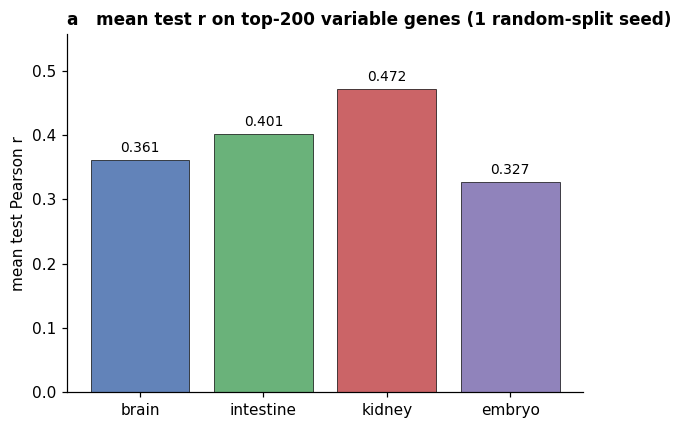

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 4))
xs = np.arange(len(TISSUES))

means = per_tissue['mean_r'].to_numpy()
stds  = per_tissue['std_r'].fillna(0).to_numpy()
n_seeds = int(per_tissue['n_seeds'].iloc[0])

bars = ax.bar(xs, means, yerr=stds if n_seeds > 1 else None,
              capsize=4 if n_seeds > 1 else 0,
              color=[TISSUE_COLORS[t] for t in TISSUES],
              edgecolor='black', linewidth=0.5, alpha=0.88)

if n_seeds > 1:
    rng = np.random.default_rng(0)
    for i, t in enumerate(TISSUES):
        ys = per_run[per_run['tissue'] == t]['mean_test_r'].to_numpy()
        xj = i + rng.uniform(-0.10, 0.10, len(ys))
        ax.scatter(xj, ys, s=22, color='black', alpha=0.65, zorder=3)

for i, (m, s) in enumerate(zip(means, stds)):
    label = f'{m:.3f}+/-{s:.3f}' if n_seeds > 1 else f'{m:.3f}'
    ax.text(i, m + (s if n_seeds > 1 else 0) + 0.008, label,
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(xs)
ax.set_xticklabels([t.replace('mouse_', '') for t in TISSUES])
ax.set_ylabel('mean test Pearson r')
seed_caption = f'{n_seeds} random-split seed' + ('s' if n_seeds > 1 else '')
ax.set_title(f'a   mean test r on top-{N_TOP} variable genes ({seed_caption})')
ax.set_ylim(0, max(means + stds) * 1.18)

plt.tight_layout()
plt.savefig('panel_a_performance_bars.pdf', bbox_inches='tight')
plt.show()

## panel B — performance-ranked tier curve, top-50 to top-200

Per tissue: rank genes by test Pearson r (post-hoc), report mean r for the top-N.

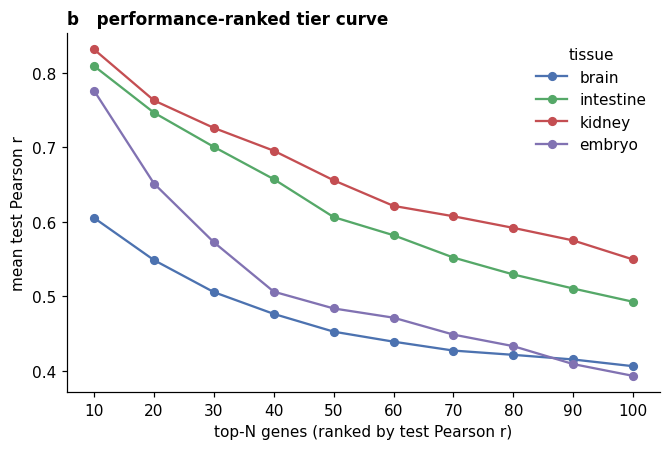

In [15]:
perf_tier_rows = []
for tissue in TISSUES:
    for seed in SEEDS:
        sub = df[(df['tissue'] == tissue) & (df['seed'] == seed)]
         
        sub = (df[(df['tissue'] == tissue) & (df['seed'] == seed)]
               .sort_values('test_pearson', ascending=False))
        
        if sub.empty:
            continue
        sub = sub.nsmallest(TOP_N, 'rank') 
        for tier in TIERS:
            perf_tier_rows.append({
                'tissue':      tissue,
                'seed':        seed,
                'tier':        tier,
                'mean_test_r': sub.head(tier)['test_pearson'].mean(),
            })
perf_tier_df  = pd.DataFrame(perf_tier_rows)
perf_tier_agg = (perf_tier_df.groupby(['tissue', 'tier'])
                 .agg(mean=('mean_test_r', 'mean'),
                      std =('mean_test_r', 'std'))
                 .reset_index())

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for tissue in TISSUES:
    sub = perf_tier_agg[perf_tier_agg['tissue'] == tissue].sort_values('tier')
    yerr = sub['std'].fillna(0) if len(SEEDS) > 1 else None
    ax.errorbar(sub['tier'], sub['mean'], yerr=yerr,
                marker='o', markersize=5, capsize=3, linewidth=1.5,
                color=TISSUE_COLORS[tissue], label=tissue.replace('mouse_', ''))

ax.set_xlabel('top-N genes (ranked by test Pearson r)')
ax.set_ylabel('mean test Pearson r')
ax.set_xticks(TIERS)
ax.set_title('b   performance-ranked tier curve')
ax.legend(loc='upper right', title='tissue')
plt.tight_layout()
plt.savefig('panel_b_perf_tier_curve.pdf', bbox_inches='tight')
plt.show()
perf_tier_agg.to_csv('perf_tier_curve.csv', index=False)

## panel D prep — coverage data

Three sources tried in order:
1. Coverage column already in the rank CSV (detected above as `cov_col`)
2. Computed from the expression memmap on training cells only
3. Fallback: skip coverage; panel D becomes a 2-curve overlay (variance + performance)

Option 2 is preferred over computing from h5ad because the trainer uses memmap, and the same convention can be applied here without depending on h5ad existence.

In [16]:
coverage_by_tissue = {}

if cov_col is not None:
    for tissue in TISSUES:
        sub = df[df['tissue'] == tissue].drop_duplicates('gene_idx')
        coverage_by_tissue[tissue] = sub.set_index('gene_idx')[cov_col].to_dict()
    print(f'Coverage loaded from rank CSV column "{cov_col}" for all tissues')
else:
    # Compute coverage from expression memmap.
    # The trainer reads expression via VisiumHDPredictionDataset; here we look for the
    # raw memmap file directly. Common patterns: 'expression.dat', 'expr.dat', '*.npy'.
    for tissue in TISSUES:
        cdir = cache_dir(tissue)
        # Find the expression memmap. Adjust the pattern if your cache uses a different name.
        candidates = (list(cdir.glob('expression*.dat'))
                      + list(cdir.glob('expr*.dat'))
                      + list(cdir.glob('expression*.npy'))
                      + list(cdir.glob('expr*.npy')))
        if not candidates:
            print(f'  {tissue}: no expression memmap found in {cdir}; skipping')
            continue
        expr_path = candidates[0]

        # Determine shape: assume n_cells = len(meta), n_genes = full panel.
        # If a shape file exists, prefer it.
        shape_path = cdir / 'expression_shape.json'
        meta_full = pd.read_csv(cdir / 'meta.csv')
        n_cells = len(meta_full)
        if shape_path.exists():
            import json
            shape = tuple(json.loads(shape_path.read_text()).get('shape', [n_cells, -1]))
        else:
            # Try to infer n_genes from file size; assume float32 dtype (4 bytes).
            try:
                bytes_total = expr_path.stat().st_size
                n_genes = bytes_total // (n_cells * 4)
                shape = (n_cells, n_genes)
            except Exception as e:
                print(f'  {tissue}: could not infer memmap shape ({e}); skipping')
                continue

        try:
            expr = np.memmap(expr_path, dtype='float32', mode='r', shape=shape)
        except Exception as e:
            print(f'  {tissue}: memmap load failed ({e}); skipping')
            continue

        # Train cells only (random split — use train portion of any seed's splits file)
        any_exp_dir = experiment_dir(tissue, SEEDS[0])
        splits_path = any_exp_dir / f'splits_seed_{SEEDS[0]}.npz'
        if splits_path.exists():
            train_rows_in_all_meta = np.load(splits_path)['train_idx']
            # Reconstruct all_meta ordering to map back to mmap_idx
            splits_layout_path = cdir / 'splits' / LAYOUT / 'splits.csv'
            if splits_layout_path.exists():
                splits_layout = pd.read_csv(splits_layout_path)
                meta_merged = meta_full.merge(splits_layout, on='mmap_idx', how='inner')
            else:
                meta_merged = meta_full.assign(split='train')
            all_meta = pd.concat([meta_merged[meta_merged['split'] == s]
                                  for s in ['train', 'val', 'test']]).reset_index(drop=True)
            train_mmap_idx = all_meta.iloc[train_rows_in_all_meta]['mmap_idx'].to_numpy()
        else:
            print(f'  {tissue}: no splits file; using all cells for coverage')
            train_mmap_idx = np.arange(n_cells)

        # Compute coverage in chunks to avoid loading everything into memory
        cov = np.zeros(shape[1], dtype=np.float64)
        chunk = 8192
        rows_sorted = np.sort(train_mmap_idx)
        for start in range(0, len(rows_sorted), chunk):
            x = np.asarray(expr[rows_sorted[start:start+chunk]])
            cov += (x > 0).sum(axis=0)
        cov = cov / len(rows_sorted)

        # Map to gene_idx (matches positions in the expression matrix)
        sub = df[df['tissue'] == tissue].drop_duplicates('gene_idx')
        cov_by_idx = {int(gi): float(cov[int(gi)]) for gi in sub['gene_idx']}
        coverage_by_tissue[tissue] = cov_by_idx
        print(f'  {tissue}: computed coverage for {len(cov_by_idx)} genes '
              f'(median = {np.median(list(cov_by_idx.values())):.3f})')

def _lookup_cov(row):
    d = coverage_by_tissue.get(row['tissue'])
    if d is None:
        return np.nan
    return d.get(int(row['gene_idx']), np.nan)

df['coverage'] = df.apply(_lookup_cov, axis=1)
HAS_COVERAGE = df['coverage'].notna().any()
print(f'\nHAS_COVERAGE = {HAS_COVERAGE}')
if HAS_COVERAGE:
    print(df.groupby('tissue')['coverage'].describe().round(3))

Coverage loaded from rank CSV column "coverage" for all tissues

HAS_COVERAGE = True
                 count   mean    std    min    25%    50%    75%    max
tissue                                                                 
mouse_brain      200.0  0.517  0.118  0.180  0.432  0.491  0.583  0.867
mouse_embryo     200.0  0.365  0.129  0.215  0.283  0.317  0.407  0.860
mouse_intestine  200.0  0.388  0.157  0.141  0.272  0.340  0.466  0.893
mouse_kidney     200.0  0.401  0.164  0.126  0.298  0.345  0.459  0.939


## panel D — 3-curve tier overlay per tissue (variance, coverage, performance)

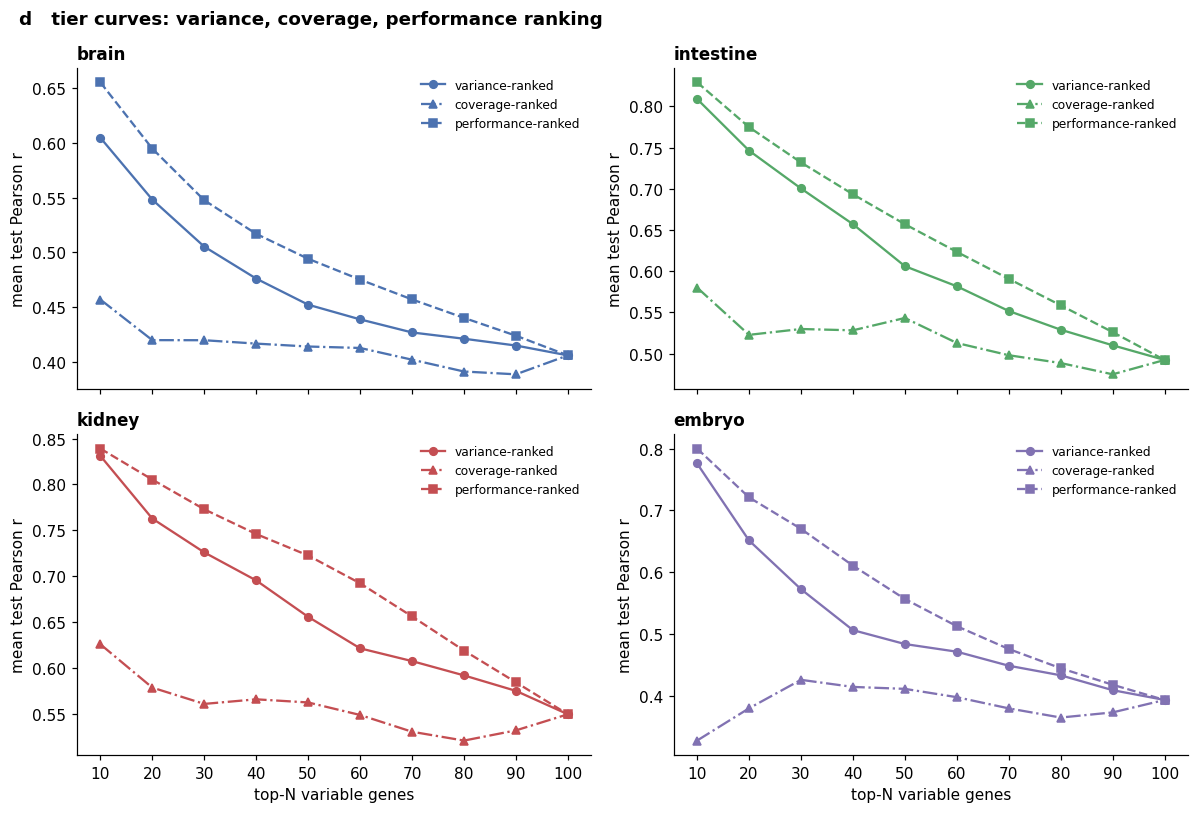

In [17]:
def compute_tier_curve(sub, rank_col, ascending, tiers=TIERS, gene_value='test_pearson'):
    s = sub.dropna(subset=[rank_col]).sort_values(rank_col, ascending=ascending)
    return [(t, s.head(t)[gene_value].mean()) for t in tiers]

tier_rows = []
for tissue in TISSUES:
    for seed in SEEDS:
        sub = df[(df['tissue'] == tissue) & (df['seed'] == seed)]
        if sub.empty:
            continue
        sub = sub.nsmallest(TOP_N, 'rank')
        for t, v in compute_tier_curve(sub, 'rank', ascending=True):
            tier_rows.append({'tissue': tissue, 'seed': seed, 'ranking': 'variance',
                              'tier': t, 'mean_test_r': v})
        for t, v in compute_tier_curve(sub, 'test_pearson', ascending=False):
            tier_rows.append({'tissue': tissue, 'seed': seed, 'ranking': 'performance',
                              'tier': t, 'mean_test_r': v})
        if HAS_COVERAGE:
            for t, v in compute_tier_curve(sub, 'coverage', ascending=False):
                tier_rows.append({'tissue': tissue, 'seed': seed, 'ranking': 'coverage',
                                  'tier': t, 'mean_test_r': v})

tier_df = pd.DataFrame(tier_rows)
tier_agg = (tier_df.groupby(['tissue', 'ranking', 'tier'])
            .agg(mean=('mean_test_r', 'mean'),
                 std =('mean_test_r', 'std'))
            .reset_index())

ranking_styles = {
    'variance':    dict(marker='o', linestyle='-',  label='variance-ranked'),
    'coverage':    dict(marker='^', linestyle='-.', label='coverage-ranked'),
    'performance': dict(marker='s', linestyle='--', label='performance-ranked'),
}
order = ['variance', 'coverage', 'performance'] if HAS_COVERAGE else ['variance', 'performance']

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=False)
axes = axes.flatten()

for ax, tissue in zip(axes, TISSUES):
    base_color = TISSUE_COLORS[tissue]
    for ranking in order:
        sub = tier_agg[(tier_agg['tissue'] == tissue) &
                       (tier_agg['ranking'] == ranking)].sort_values('tier')
        yerr = sub['std'].fillna(0) if len(SEEDS) > 1 else None
        style = ranking_styles[ranking]
        ax.errorbar(sub['tier'], sub['mean'], yerr=yerr, capsize=3,
                    markersize=5, linewidth=1.5, color=base_color, **style)
    ax.set_title(tissue.replace('mouse_', ''))
    ax.set_xticks(TIERS)
    ax.set_ylabel('mean test Pearson r')
    ax.legend(fontsize=8, loc='best')

for ax in axes[-2:]:
    ax.set_xlabel('top-N variable genes')

fig.suptitle('d   tier curves: variance, coverage, performance ranking',
             fontsize=12, fontweight='bold', x=0.02, ha='left')
plt.tight_layout()
plt.savefig('panel_d_tier_overlay.pdf', bbox_inches='tight')
plt.show()
tier_agg.to_csv('tier_curve_3way.csv', index=False)

## gene-selection helper for panel C

For each tissue: top-30 most-predicted genes (star next to canonical markers), plus canonical-marker hits.

**Selection criteria — pick 2 genes per tissue (brain, embryo):**

1. **One canonical, high-r marker.** A gene a reviewer recognizes immediately as a cell-type or tissue marker, with r near the tissue's top.
2. **One canonical, moderate-r marker.** Same recognition, lower r (around the tissue mean). Protects against cherry-picking accusations.

Skip housekeeping genes — easy for any model. Skip non-marker top-r hits unless justifiable biologically.

In [18]:
CANONICAL = {
    'mouse_brain': [
        'Slc17a7','Slc17a6','Rorb','Tbr1','Foxp2','Satb2','Bcl11b','Fezf2','Cux2','Pou3f2',
        'Gad1','Gad2','Pvalb','Sst','Vip','Lhx6','Reln','Calb1','Calb2',
        'Gfap','Aqp4','Aldh1l1','S100b','Slc1a3',
        'Mog','Mbp','Olig1','Olig2','Plp1','Pdgfra',
        'Cx3cr1','Csf1r','Aif1','P2ry12','Tmem119',
        'Pecam1','Cldn5','Tek','Flt1',
        'Prox1','Wfs1','Dcn',
    ],
    'mouse_embryo': [
        'Tnnt2','Myh6','Myh7','Nkx2-5','Gata4','Tbx5',
        'Afp','Alb','Apoa1','Hbb-y','Hbb-bh1','Gata1','Klf1',
        'Sftpc','Sftpb','Nkx2-1',
        'Sox2','Pax6','Nes','Tubb3','Foxa2','Olig3',
        'Myog','Myod1','Pax3','Pax7','Myf5','Tcf15',
        'Hoxd13','Tbx4','Prx1','Sox9',
        'Krt14','Krt5','Krt18','Krt8',
        'Pecam1','Cdh5','Kdr',
        'Cdx2','Foxa1','Sox17',
    ],
    'mouse_intestine': [
        'Vil1','Alpi','Fabp1','Fabp2','Apoa4',
        'Muc2','Tff3','Klf4',
        'Lyz1','Defa','Lgr5','Olfm4','Ascl2',
        'Chga','Chgb',
        'Dclk1','Pou2f3',
        'Acta2','Myh11','Vim',
    ],
    'mouse_kidney': [
        'Nphs1','Nphs2','Wt1','Synpo',
        'Slc34a1','Lrp2','Slc5a2','Slc12a1','Slc22a8',
        'Slc12a3','Aqp2','Aqp3','Calb1','Umod',
        'Pecam1','Pdgfrb','Acta2',
        'Cd68','Ptprc',
    ],
}

for tissue in TISSUES:
    sub = (df[df['tissue'] == tissue]
           .groupby(['gene_idx', 'gene_name'])
           .agg(mean_r=('test_pearson', 'mean'),
                std_r =('test_pearson', 'std'),
                rank_var=('rank', 'first'))
           .reset_index()
           .sort_values('mean_r', ascending=False))

    print(f'\n{"="*72}')
    print(f'{tissue}  |  n_genes={len(sub)}  |  mean r={sub["mean_r"].mean():.3f}')
    print('='*72)

    canon = set(CANONICAL.get(tissue, []))
    sub['is_canonical'] = sub['gene_name'].isin(canon)

    print('\n  Top-30 by test r:')
    top30 = sub.head(30).copy()
    top30['marker'] = top30['is_canonical'].map({True: '*', False: ' '})
    cols = ['marker', 'gene_name', 'mean_r', 'rank_var']
    if 'std_r' in top30 and top30['std_r'].notna().any():
        cols.append('std_r')
    print(top30[cols].to_string(index=False))

    canonical_hits = sub[sub['is_canonical']].head(20)
    print('\n  Canonical markers in the top-200 (* above):')
    if canonical_hits.empty:
        print('    (none from the curated list - extend CANONICAL above)')
    else:
        print(canonical_hits[['gene_name', 'mean_r', 'rank_var']].to_string(index=False))


mouse_brain  |  n_genes=200  |  mean r=0.361

  Top-30 by test r:
marker gene_name   mean_r  rank_var
            Nrgn 0.738395         2
         Camk2n1 0.683245         1
            Pcp4 0.682171         5
           Ptk2b 0.679723        11
           Olfm1 0.670942         4
     *   Slc17a7 0.649535        29
          Snap25 0.616886        16
             Cck 0.613390         9
           Nptxr 0.612116        88
          Camk2a 0.609462         8
          Snhg11 0.592555         6
     *      Plp1 0.576778       155
         Rasgrp1 0.562746        51
          Atp2b1 0.543809        73
            Ncdn 0.542285        14
           Mef2c 0.541995       186
            Chn1 0.538892        79
          Ppp3ca 0.535233        86
           Scn1b 0.522872        10
          Arpp21 0.519719       157
     *       Mbp 0.510487       138
          Nap1l5 0.509333        31
           Uchl1 0.508342        17
           Kalrn 0.506518       118
           Akap5 0.501391       1

## panel C — observed vs predicted spatial maps

Loads from trainer outputs:
- `test_y_pred_seed_X.npy`, `test_y_true_seed_X.npy` — `(n_test_cells, n_genes)` arrays, genes in rank-CSV order
- `splits_seed_X.npz` — `train_idx`/`val_idx`/`test_idx` into the train+val+test concatenated `meta`
- `cache_{tissue}/meta.csv` + `cache_{tissue}/splits/{LAYOUT}/splits.csv` — per-cell metadata, reordered to match the trainer's all_meta concatenation

The inspect cell above showed the meta.csv columns — adjust `_pick_xy_columns()` below if your meta uses different coordinate names than the defaults.

Representative genes were selected from the top-200 training-variance-ranked target genes to illustrate distinct morphology-associated expression patterns. For brain, Slc17a7 and Plp1 were chosen to show neuronal and myelin-associated spatial programs. For embryo, Igf2 and Tubb3 were chosen to show high-performing developmental and neural-associated spatial patterns. Quantitative claims are based on all target genes, not these examples alone.

In [19]:
# === EDIT THESE: chosen genes ====================================================
#BRAIN_GENES  = ['Slc17a7', 'Camk2n1']     # e.g. ['Mog', 'Slc17a7']
#EMBRYO_GENES = ['Tubb3', 'Col1a1']     # e.g. ['Tnnt2', 'Pax6']

BRAIN_GENES  = ['Slc17a7', 'Plp1']
EMBRYO_GENES = ['Igf2', 'Tubb3']
PANEL_C_SEED = 42

def _pick_xy_columns(meta_df):
    x_candidates = ['x_centroid', 'x', 'X', 'centroid_x', 'centroid_x_um', 'cx',
                    'pxl_col_in_fullres', 'array_col']
    y_candidates = ['y_centroid', 'y', 'Y', 'centroid_y', 'centroid_y_um', 'cy',
                    'pxl_row_in_fullres', 'array_row']
    x_col = next((c for c in x_candidates if c in meta_df.columns), None)
    y_col = next((c for c in y_candidates if c in meta_df.columns), None)
    return x_col, y_col

def _build_all_meta(tissue):
    """Reconstruct the train+val+test concatenated meta as the trainer does internally."""
    meta = pd.read_csv(cache_dir(tissue) / 'meta.csv')
    splits_layout_path = cache_dir(tissue) / 'splits' / LAYOUT / 'splits.csv'
    if splits_layout_path.exists():
        splits = pd.read_csv(splits_layout_path)
        meta = meta.merge(splits, on='mmap_idx', how='inner')
    elif 'split' not in meta.columns:
        meta['split'] = 'train'
    all_meta = pd.concat([meta[meta['split'] == s] for s in ['train', 'val', 'test']]
                         ).reset_index(drop=True)
    return all_meta

def load_predictions(tissue, gene_name, seed=PANEL_C_SEED):
    """Return DataFrame with ['x', 'y', 'observed', 'predicted'] for one gene on test cells."""
    exp_dir = experiment_dir(tissue, seed)
    pred_path  = exp_dir / f'test_y_pred_seed_{seed}.npy'
    true_path  = exp_dir / f'test_y_true_seed_{seed}.npy'
    splits_path = exp_dir / f'splits_seed_{seed}.npz'

    for p in (pred_path, true_path, splits_path):
        if not p.exists():
            raise FileNotFoundError(f'Missing {p}')

    y_pred = np.load(pred_path)
    y_true = np.load(true_path)

    # Locate the gene column in the (cells, genes) arrays via the rank CSV order
    ranks = pd.read_csv(rank_csv(tissue)).reset_index(drop=True)
    matches = np.where(ranks['gene_name'].values == gene_name)[0]
    if len(matches) == 0:
        raise KeyError(f'{gene_name!r} not in top-{N_TOP} list for {tissue}')
    gene_col = int(matches[0])

    # Test-cell metadata
    test_idx = np.load(splits_path)['test_idx']
    all_meta = _build_all_meta(tissue)
    test_meta = all_meta.iloc[test_idx].reset_index(drop=True)

    x_col, y_col = _pick_xy_columns(test_meta)
    if x_col is None or y_col is None:
        raise KeyError(f'No x/y columns found in meta. Available: {list(test_meta.columns)}')

    n = min(len(test_meta), y_pred.shape[0], y_true.shape[0])
    if not (len(test_meta) == y_pred.shape[0] == y_true.shape[0]):
        print(f'  [warn] length mismatch for {tissue}/{gene_name}: '
              f'meta={len(test_meta)}, pred={y_pred.shape[0]}, true={y_true.shape[0]} '
              f'— truncating to {n}')

    return pd.DataFrame({
        'x': test_meta[x_col].to_numpy()[:n],
        'y': test_meta[y_col].to_numpy()[:n],
        'observed':  y_true[:n, gene_col],
        'predicted': y_pred[:n, gene_col],
    })

# Smoke test
try:
    probe = BRAIN_GENES[0] if BRAIN_GENES[0] != 'REPLACE_WITH_GENE_1' else 'Gad1'
    test = load_predictions('mouse_brain', probe)
    print(f'Smoke test OK — {len(test)} cells loaded for {probe} (mouse_brain, seed {PANEL_C_SEED})')
    print(test.head())
    print(f'  observed range: {test["observed"].min():.3f} to {test["observed"].max():.3f}')
    print(f'  predicted range: {test["predicted"].min():.3f} to {test["predicted"].max():.3f}')
    print(f'  Pearson: {np.corrcoef(test["observed"], test["predicted"])[0,1]:.3f}')
except Exception as e:
    print(f'Smoke test failed: {type(e).__name__}: {e}')
    print('Inspect the meta.csv columns and adjust _pick_xy_columns() if needed.')

Smoke test OK — 4585 cells loaded for Slc17a7 (mouse_brain, seed 42)
              x             y  observed  predicted
0  17655.337280   7587.015885  1.123272  -0.008667
1  18791.319200  14100.029079 -0.853830  -0.628906
2  16160.854849  13693.579219 -0.853830  -0.988281
3  20669.624548  15888.609113 -0.853830  -0.808594
4  20647.614980  17711.436944 -0.853830  -0.699219
  observed range: -0.854 to 2.470
  predicted range: -1.359 to 1.695
  Pearson: 0.650


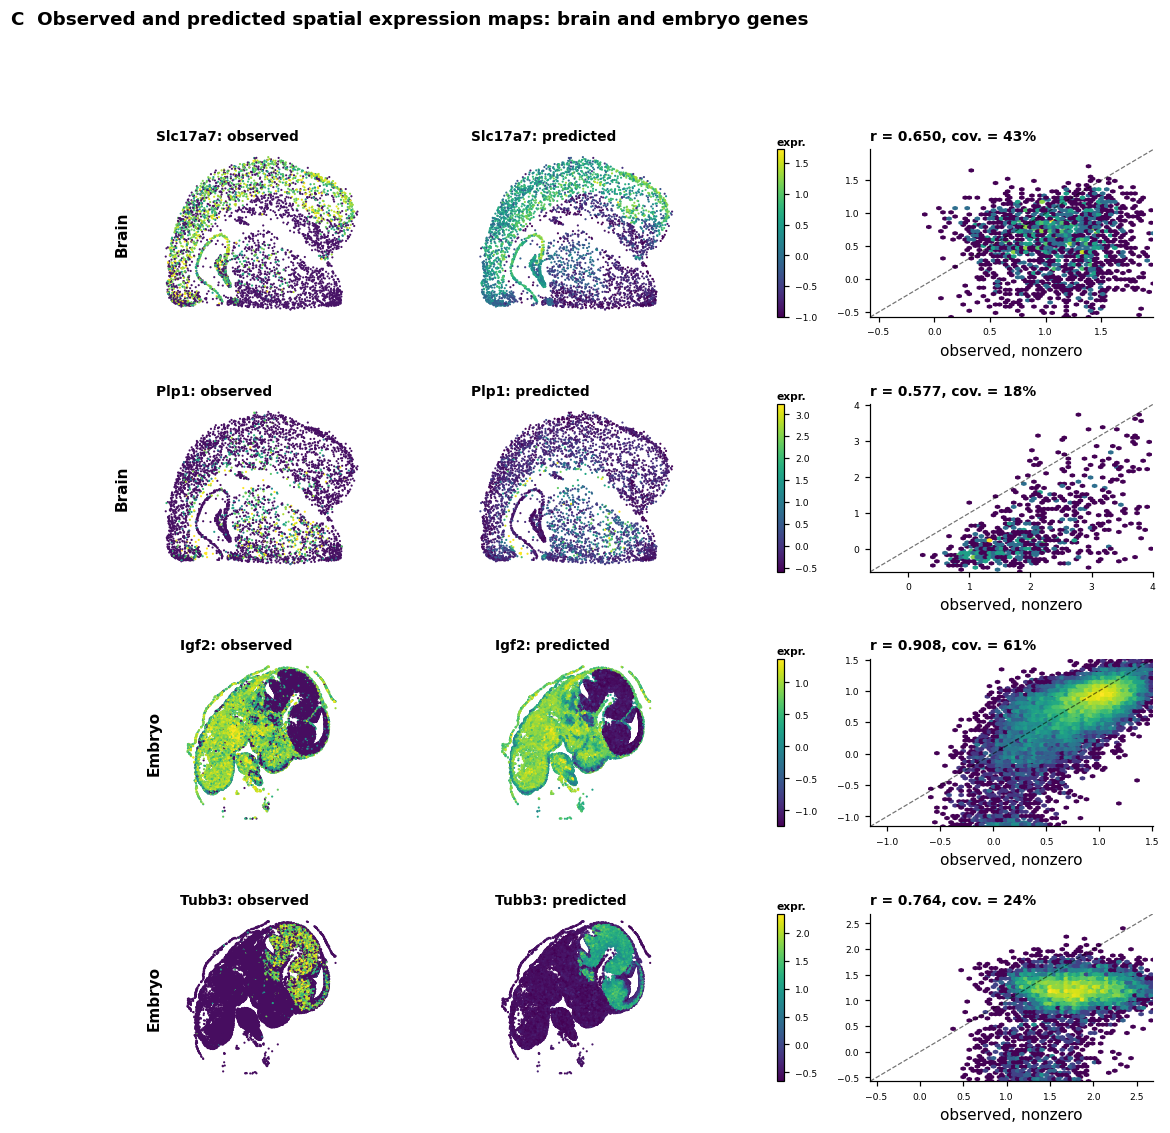

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# Recommended example genes
BRAIN_GENES = ["Slc17a7", "Plp1"]
EMBRYO_GENES = ["Igf2", "Tubb3"]

TISSUE_LABELS = {
    "mouse_brain": "Brain",
    "mouse_embryo": "Embryo",
    "mouse_intestine": "Intestine",
    "mouse_kidney": "Kidney",
}

MAP_CMAP = "viridis"
HEX_CMAP = "viridis"

MAP_Q_LOW = 1
MAP_Q_HIGH = 99

HEX_Q_LOW = 1
HEX_Q_HIGH = 99

ZERO_ROUND_DIGITS = 6
SHOW_COVERAGE_IN_HEXBIN_TITLE = True
REMOVE_ZERO_OBSERVED_FROM_HEXBIN = True


def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return np.nan
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])


def percentile_limits(values, q_low=1, q_high=99):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return -1.0, 1.0

    vmin = np.nanpercentile(values, q_low)
    vmax = np.nanpercentile(values, q_high)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return -1.0, 1.0

    if np.isclose(vmin, vmax):
        pad = 1.0 if np.isclose(vmin, 0) else abs(vmin) * 0.1
        return vmin - pad, vmax + pad

    return float(vmin), float(vmax)


def observed_coverage_from_pileup(obs):
    """
    Estimate observed coverage from the zero-expression pileup after z-score normalization.

    Raw zero expression becomes one repeated z-score value:
        z = (0 - train_mean) / train_std

    Returns:
        coverage: estimated fraction of nonzero observed cells
        zero_frac: estimated fraction of zero observed cells
        zero_level: repeated z-score value corresponding to raw zero
    """
    obs = np.asarray(obs, dtype=float)
    obs = obs[np.isfinite(obs)]

    if len(obs) == 0:
        return np.nan, np.nan, None

    rounded = np.round(obs, ZERO_ROUND_DIGITS)

    low_cut = np.nanpercentile(rounded, 50)
    low_vals = rounded[rounded <= low_cut]

    if len(low_vals) == 0:
        return np.nan, np.nan, None

    vals, counts = np.unique(low_vals, return_counts=True)
    idx = np.argmax(counts)

    zero_level = vals[idx]
    zero_frac = counts[idx] / len(rounded)
    coverage = 1.0 - zero_frac

    return float(coverage), float(zero_frac), float(zero_level)


def format_map_axis(ax):
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


def format_hex_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=6)


def plot_gene_triplet(tissue, gene_name, seed, fig, gs_row, point_size=2, show_xlabel=True):
    data = load_predictions(tissue, gene_name, seed).copy()

    required_cols = ["x", "y", "observed", "predicted"]
    missing = [c for c in required_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Missing columns for {tissue} / {gene_name}: {missing}")

    for col in required_cols:
        data[col] = data[col].astype(float)

    valid = (
        np.isfinite(data["x"].to_numpy()) &
        np.isfinite(data["y"].to_numpy()) &
        np.isfinite(data["observed"].to_numpy()) &
        np.isfinite(data["predicted"].to_numpy())
    )

    data = data.loc[valid].copy()

    if len(data) == 0:
        raise ValueError(f"No valid cells for {tissue} / {gene_name}")

    obs_v = data["observed"].to_numpy()
    pred_v = data["predicted"].to_numpy()

    pearson_all = safe_pearson(obs_v, pred_v)
    coverage, zero_frac, zero_level = observed_coverage_from_pileup(obs_v)

    map_values = np.concatenate([obs_v, pred_v])
    map_vmin, map_vmax = percentile_limits(
        map_values,
        q_low=MAP_Q_LOW,
        q_high=MAP_Q_HIGH,
    )

    ax0 = fig.add_subplot(gs_row[0])
    sc0 = ax0.scatter(
        data["x"],
        data["y"],
        c=obs_v,
        s=point_size,
        cmap=MAP_CMAP,
        vmin=map_vmin,
        vmax=map_vmax,
        edgecolors="none",
        rasterized=True,
    )
    format_map_axis(ax0)
    ax0.set_title(f"{gene_name}: observed", fontsize=9, fontweight="bold")

    ax1 = fig.add_subplot(gs_row[1])
    sc1 = ax1.scatter(
        data["x"],
        data["y"],
        c=pred_v,
        s=point_size,
        cmap=MAP_CMAP,
        vmin=map_vmin,
        vmax=map_vmax,
        edgecolors="none",
        rasterized=True,
    )
    format_map_axis(ax1)
    ax1.set_title(f"{gene_name}: predicted", fontsize=9, fontweight="bold")

    cax = fig.add_subplot(gs_row[2])
    cbar = fig.colorbar(sc1, cax=cax)
    cbar.ax.tick_params(labelsize=6)
    cbar.ax.set_title("expr.", fontsize=7, pad=3)

        # Hexbin visualization.
    # We optionally remove the zero-observed expression pileup from the hexbin only.
    # Pearson r and coverage are still computed using all held-out cells.
    if REMOVE_ZERO_OBSERVED_FROM_HEXBIN and zero_level is not None:
        keep_hex = np.round(obs_v, ZERO_ROUND_DIGITS) != np.round(zero_level, ZERO_ROUND_DIGITS)

        hex_obs = obs_v[keep_hex]
        hex_pred = pred_v[keep_hex]

        # Fallback in case filtering removes too much.
        if len(hex_obs) < 10:
            hex_obs = obs_v.copy()
            hex_pred = pred_v.copy()
            hex_xlabel = "observed"
            hex_title = f"r = {pearson_all:.3f}, cov. = {coverage:.0%}"
        else:
            hex_xlabel = "observed, nonzero"
            hex_title = f"r = {pearson_all:.3f}, cov. = {coverage:.0%}"
    else:
        hex_obs = obs_v.copy()
        hex_pred = pred_v.copy()
        hex_xlabel = "observed"
        hex_title = f"r = {pearson_all:.3f}, cov. = {coverage:.0%}"

    hex_values = np.concatenate([hex_obs, hex_pred])
    hex_lo, hex_hi = percentile_limits(
        hex_values,
        q_low=HEX_Q_LOW,
        q_high=HEX_Q_HIGH,
    )

    hex_pad = 0.04 * (hex_hi - hex_lo)
    hex_lo -= hex_pad
    hex_hi += hex_pad

    ax2 = fig.add_subplot(gs_row[3])
    ax2.hexbin(
        hex_obs,
        hex_pred,
        gridsize=70,
        cmap=HEX_CMAP,
        mincnt=1,
        bins="log",
        extent=(hex_lo, hex_hi, hex_lo, hex_hi),
        rasterized=True,
    )

    ax2.plot(
        [hex_lo, hex_hi],
        [hex_lo, hex_hi],
        color="black",
        linestyle="--",
        linewidth=0.8,
        alpha=0.55,
    )

    ax2.set_xlim(hex_lo, hex_hi)
    ax2.set_ylim(hex_lo, hex_hi)
    ax2.set_xlabel(hex_xlabel if show_xlabel else "", fontsize=10)
    ax2.set_ylabel("")

    if SHOW_COVERAGE_IN_HEXBIN_TITLE and np.isfinite(coverage):
        ax2.set_title(
            hex_title,
            fontsize=9,
            fontweight="bold",
        )
    else:
        ax2.set_title(
            f"r = {pearson_all:.3f}",
            fontsize=9,
            fontweight="bold",
        )

    format_hex_axis(ax2)

    tissue_label = TISSUE_LABELS.get(
        tissue,
        tissue.replace("mouse_", "").replace("_", " ").title(),
    )

    ax0.text(
        -0.16,
        0.5,
        tissue_label,
        transform=ax0.transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )


to_plot = (
    [("mouse_brain", g) for g in BRAIN_GENES] +
    [("mouse_embryo", g) for g in EMBRYO_GENES]
)

n_rows = len(to_plot)

fig = plt.figure(figsize=(11.8, 2.75 * n_rows))

gs = GridSpec(
    n_rows,
    4,
    figure=fig,
    width_ratios=[1.05, 1.05, 0.035, 1.30],
    hspace=0.52,
    wspace=0.46,
)

for i, (tissue, gene) in enumerate(to_plot):
    if gene.startswith("REPLACE_WITH_GENE"):
        ax = fig.add_subplot(gs[i, :])
        ax.axis("off")
        ax.text(
            0.5,
            0.5,
            f"Set {tissue} gene #{i % 2 + 1} above and rerun",
            ha="center",
            va="center",
            fontsize=11,
            color="gray",
        )
        continue

    try:
        plot_gene_triplet(
            tissue=tissue,
            gene_name=gene,
            seed=PANEL_C_SEED,
            fig=fig,
            gs_row=[gs[i, 0], gs[i, 1], gs[i, 2], gs[i, 3]],
            point_size=2,
        )
    except Exception as e:
        ax = fig.add_subplot(gs[i, :])
        ax.axis("off")
        ax.text(
            0.5,
            0.5,
            f"{tissue} / {gene} load error: {e}",
            ha="center",
            va="center",
            fontsize=9,
            color="red",
        )

fig.suptitle(
    "C  Observed and predicted spatial expression maps: brain and embryo genes",
    fontsize=12,
    fontweight="bold",
    x=0.02,
    ha="left",
    y=0.995,
)

plt.savefig("panel_c_spatial_maps.pdf", bbox_inches="tight")
plt.savefig("panel_c_spatial_maps.png", dpi=300, bbox_inches="tight")
plt.show()

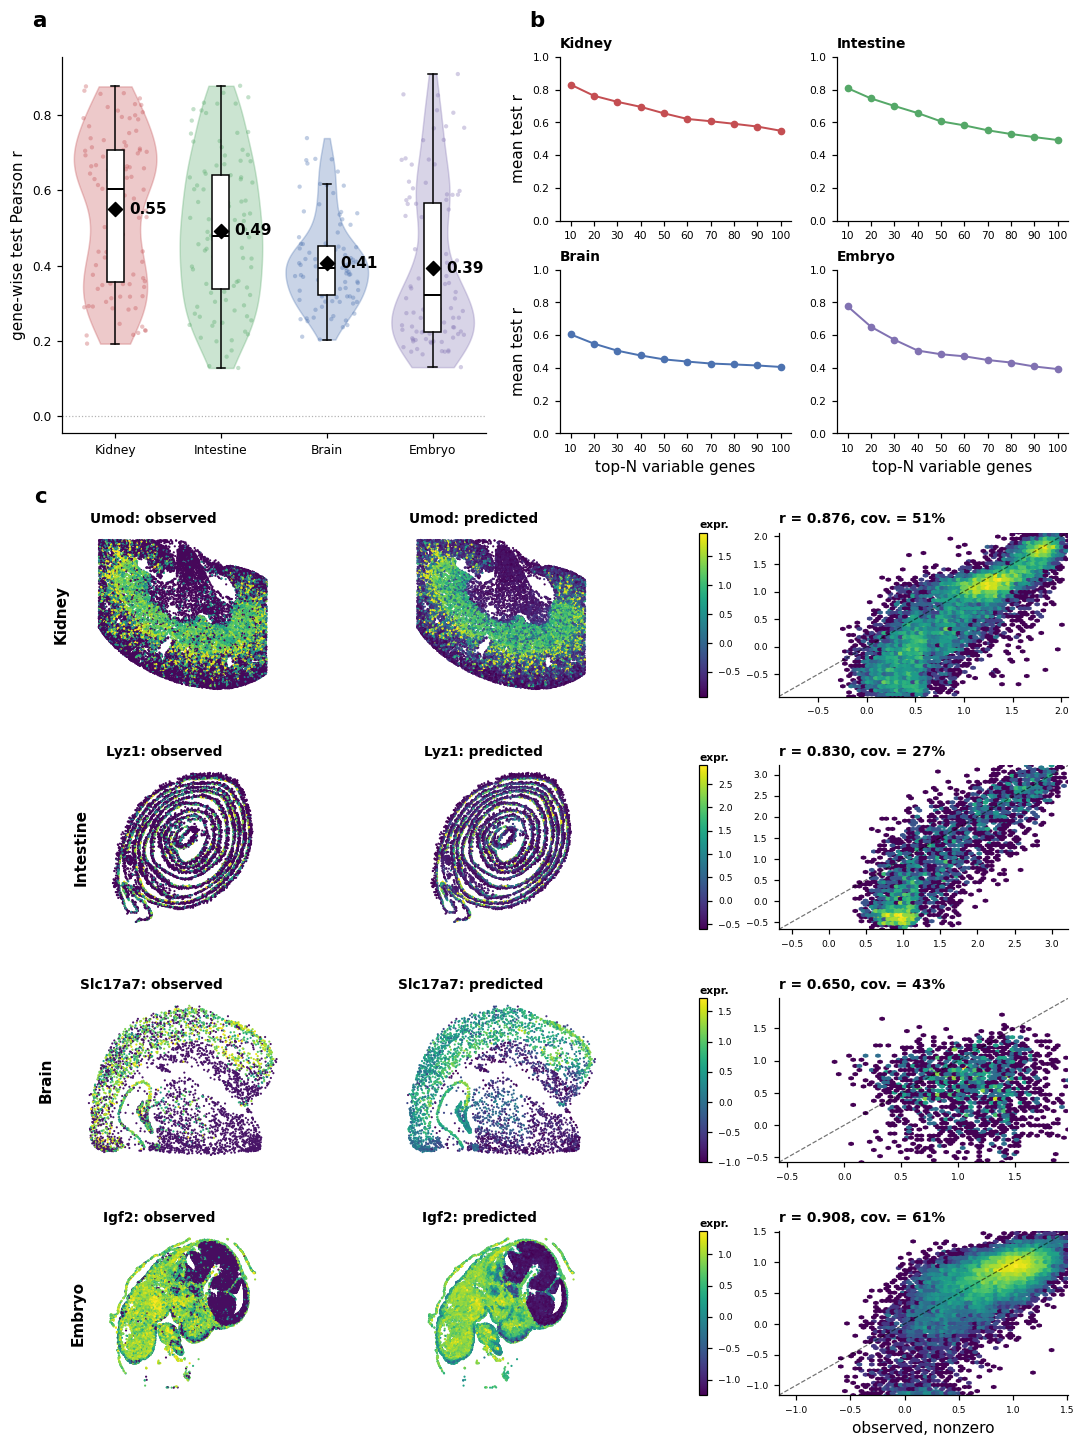

In [22]:
# === Violin panel function ==================================================
def plot_violin_panel(ax, gene_r_by_tissue, tissue_order):
    """Violin + box + strip + mean-diamond for per-gene test r across tissues."""
    positions = np.arange(len(tissue_order))
    data_list = [np.asarray(gene_r_by_tissue[t], dtype=float) for t in tissue_order]
    data_list = [d[np.isfinite(d)] for d in data_list]

    # Violin bodies, clipped to the actual data range (no KDE tail artifact)
    parts = ax.violinplot(data_list, positions=positions,
                          showextrema=False, widths=0.78)
    for i, body in enumerate(parts['bodies']):
        verts = body.get_paths()[0].vertices
        ymin, ymax = data_list[i].min(), data_list[i].max()
        verts[:, 1] = np.clip(verts[:, 1], ymin, ymax)
        color = TISSUE_COLORS[tissue_order[i]]
        body.set_facecolor(color)
        body.set_alpha(0.30)
        body.set_edgecolor(color)
        body.set_linewidth(1.0)

    # Strip of individual gene points
    rng = np.random.default_rng(0)
    for i, t in enumerate(tissue_order):
        vals = data_list[i]
        xj = positions[i] + rng.uniform(-0.30, 0.30, len(vals))
        ax.scatter(xj, vals, s=8, color=TISSUE_COLORS[t],
                   alpha=0.35, edgecolors='none', zorder=2)

    # Box plot overlay (drawn on top of the strip so it stays readable)
    ax.boxplot(data_list, positions=positions, widths=0.16,
               showfliers=False, patch_artist=True, zorder=3,
               medianprops=dict(color='black', linewidth=1.3),
               boxprops=dict(facecolor='white', edgecolor='black', linewidth=1.0),
               whiskerprops=dict(color='black', linewidth=1.0),
               capprops=dict(color='black', linewidth=1.0))

    # Mean diamond + value label
    for i, t in enumerate(tissue_order):
        m = float(np.mean(data_list[i]))
        ax.scatter(positions[i], m, marker='D', s=42, color='black', zorder=5)
        ax.text(positions[i] + 0.13, m, f'{m:.2f}', fontsize=10,
                va='center', ha='left', fontweight='bold')

    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xticks(positions)
    ax.set_xticklabels([TISSUE_LABELS.get(t, t.replace('mouse_', '')) for t in tissue_order])
    ax.set_ylabel('gene-wise test Pearson r', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# === Gene picks and tissue order ============================================
GENE_PICKS = {
    'mouse_brain':     'Slc17a7',
    'mouse_intestine': 'Lyz1',
    'mouse_kidney':    'Umod',
    'mouse_embryo':    'Igf2',
}
TISSUE_ORDER = ['mouse_kidney', 'mouse_intestine','mouse_brain',  'mouse_embryo']


# === Tier-curve aggregation (unchanged) =====================================
def compute_tier_curve(sub, rank_col, ascending, tiers=TIERS, gene_value='test_pearson'):
    s = sub.dropna(subset=[rank_col]).sort_values(rank_col, ascending=ascending)
    return [(t, s.head(t)[gene_value].mean()) for t in tiers]

tier_rows = []
for tissue in TISSUES:
    for seed in SEEDS:
        sub = df[(df['tissue'] == tissue) & (df['seed'] == seed)]
        if sub.empty:
            continue
        sub = sub.nsmallest(TOP_N, 'rank')
        for t, v in compute_tier_curve(sub, 'rank', ascending=True):
            tier_rows.append({'tissue': tissue, 'seed': seed, 'ranking': 'variance',
                              'tier': t, 'mean_test_r': v})
        for t, v in compute_tier_curve(sub, 'test_pearson', ascending=False):
            tier_rows.append({'tissue': tissue, 'seed': seed, 'ranking': 'performance',
                              'tier': t, 'mean_test_r': v})
        if HAS_COVERAGE:
            for t, v in compute_tier_curve(sub, 'coverage', ascending=False):
                tier_rows.append({'tissue': tissue, 'seed': seed, 'ranking': 'coverage',
                                  'tier': t, 'mean_test_r': v})

tier_df = pd.DataFrame(tier_rows)
tier_agg = (tier_df.groupby(['tissue', 'ranking', 'tier'])
            .agg(mean=('mean_test_r', 'mean'),
                 std =('mean_test_r', 'std'))
            .reset_index())

ranking_styles = {
    'variance':    dict(marker='o', linestyle='-',  label='var.-ranked'),
    'coverage':    dict(marker='^', linestyle='-.', label='cov.-ranked'),
    'performance': dict(marker='s', linestyle='--', label='perf.-ranked'),
}
#order = ['variance', 'coverage', 'performance'] if HAS_COVERAGE else ['variance', 'performance']
order = ['variance']

# === Combined figure ========================================================
n_map_rows      = len(TISSUE_ORDER)
top_row_height  = 4.8     # holds violin + 2x2 tier grid
map_row_height  = 2.75

fig = plt.figure(figsize=(11.8, top_row_height + n_map_rows * map_row_height))

outer = fig.add_gridspec(2, 1,
                          height_ratios=[top_row_height, n_map_rows * map_row_height],
                          hspace=0.16)

# ── Row 1: violin (left) + 2x2 tier grid (right) ────────────────────────────
top_gs = outer[0].subgridspec(1, 2, width_ratios=[1.0, 1.2], wspace=0.16)

# Left: violin
ax_violin = fig.add_subplot(top_gs[0, 0])

# mean test r per gene, averaged across seeds
gene_r = df.groupby(['tissue', 'gene_idx'])['test_pearson'].mean()

# restrict the violin to the top-N variance-ranked genes per tissue
TOP_N_VIOLIN = TOP_N             # = 100, stays coupled to the tier cap
top_var_genes = {
    t: (df[df['tissue'] == t]
        .drop_duplicates('gene_idx')
        .nsmallest(TOP_N_VIOLIN, 'rank')['gene_idx']
        .to_numpy())
    for t in TISSUE_ORDER
}

gene_r_by_tissue = {
    t: gene_r.loc[t].reindex(top_var_genes[t]).dropna().to_numpy()
    for t in TISSUE_ORDER
}
plot_violin_panel(ax_violin, gene_r_by_tissue, TISSUE_ORDER)

# Right: 2x2 tier grid
tier_gs = top_gs[0, 1].subgridspec(2, 2, hspace=0.3, wspace=0.20)
for i, tissue in enumerate(TISSUE_ORDER):
    ax = fig.add_subplot(tier_gs[i // 2, i % 2])
    base_color = TISSUE_COLORS[tissue]
    for ranking in order:
        sub = tier_agg[(tier_agg['tissue'] == tissue) &
                       (tier_agg['ranking'] == ranking)].sort_values('tier')
        yerr = sub['std'].fillna(0) if len(SEEDS) > 1 else None
        style = ranking_styles[ranking]
        ax.errorbar(sub['tier'], sub['mean'], yerr=yerr, capsize=2.5,
                    markersize=4, linewidth=1.3, color=base_color, **style)
    ax.set_title(TISSUE_LABELS.get(tissue, tissue.replace('mouse_', '')),
                 fontsize=9, fontweight='bold', loc='left')
    ax.set_xticks(TIERS)
    ax.tick_params(labelsize=7)
    if i // 2 == 1:                       # bottom row of the 2x2
        ax.set_xlabel('top-N variable genes', fontsize=10)
    if i % 2 == 0:                        # left column of the 2x2
        ax.set_ylabel('mean test r', fontsize=10)
    #if i == 0:
    #    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ── Rows 2-5: one gene per tissue (obs | pred | cbar | hexbin) — UNCHANGED ───
maps_gs = outer[1].subgridspec(n_map_rows, 4,
                                width_ratios=[1.0, 1.05, 0.035, 1.20],
                                hspace=0.42, wspace=0.36)

for i, tissue in enumerate(TISSUE_ORDER):
    gene = GENE_PICKS[tissue]
    try:
        plot_gene_triplet(
            tissue=tissue,
            gene_name=gene,
            seed=PANEL_C_SEED,
            fig=fig,
            gs_row=[maps_gs[i, 0], maps_gs[i, 1], maps_gs[i, 2], maps_gs[i, 3]],
            point_size=2,
            show_xlabel=(i == len(TISSUE_ORDER) - 1),   # only the bottom row
        )
    except Exception as e:
        ax = fig.add_subplot(maps_gs[i, :])
        ax.axis('off')
        ax.text(0.5, 0.5, f'{tissue} / {gene} load error: {e}',
                ha='center', va='center', fontsize=10, color='red')

# ── Panel labels ────────────────────────────────────────────────────────────
_total_h = top_row_height + n_map_rows * map_row_height

# ── Panel labels ────────────────────────────────────────────────────────────
def _panel_label(bbox, letter, dx=-0.012, dy=0.015):
    fig.text(bbox.x0 + dx, bbox.y1 + dy, letter,
             fontsize=14, fontweight='bold', ha='right', va='bottom')

_panel_label(ax_violin.get_position(),        'a')   # violin
_panel_label(tier_gs[0, 0].get_position(fig), 'b')   # 2×2 tier grid
_panel_label(maps_gs[0, 0].get_position(fig), 'c')   # spatial maps block

#fig.text(0.015, 0.995, 'a', fontsize=14, fontweight='bold', ha='left', va='top')
#fig.text(0.015, (n_map_rows * map_row_height) / _total_h + 0.005,'b', fontsize=14, fontweight='bold', ha='left', va='bottom')

plt.savefig('panel_c_5row.pdf', bbox_inches='tight')
plt.savefig('panel_c_5row.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
for t in TISSUE_ORDER:
    sub = df[(df['tissue'] == t) & (df['seed'] == PANEL_C_SEED)]
    cand = sub.nsmallest(TOP_N, 'rank').nlargest(15, 'test_pearson')
    print(t, list(zip(cand['gene_name'], cand['test_pearson'].round(3))))


mouse_kidney [('Umod', 0.876), ('Slc34a1', 0.864), ('Kap', 0.858), ('Gpx3', 0.856), ('Slc12a1', 0.844), ('Slc27a2', 0.829), ('Aldob', 0.826), ('Wfdc15b', 0.821), ('Miox', 0.811), ('Ass1', 0.807), ('Acsm2', 0.799), ('Acy3', 0.795), ('Egf', 0.791), ('Pck1', 0.791), ('Lrp2', 0.788)]
mouse_intestine [('Apoa1', 0.877), ('Anpep', 0.859), ('Defa21', 0.847), ('Fabp2', 0.832), ('Lyz1', 0.83), ('Reg3b', 0.83), ('Itln1', 0.815), ('Ang4', 0.812), ('Fabp6', 0.805), ('Selenop', 0.785), ('Krt19', 0.755), ('Clec2h', 0.752), ('Naaladl1', 0.75), ('Igkc', 0.731), ('Enpep', 0.729)]
mouse_brain [('Nrgn', 0.738), ('Camk2n1', 0.683), ('Pcp4', 0.682), ('Ptk2b', 0.68), ('Olfm1', 0.671), ('Slc17a7', 0.65), ('Snap25', 0.617), ('Cck', 0.613), ('Nptxr', 0.612), ('Camk2a', 0.609), ('Snhg11', 0.593), ('Rasgrp1', 0.563), ('Atp2b1', 0.544), ('Ncdn', 0.542), ('Chn1', 0.539)]
mouse_embryo [('Igf2', 0.908), ('Col3a1', 0.854), ('Col1a1', 0.852), ('Tubb2b', 0.812), ('Col1a2', 0.806), ('Tuba1a', 0.77), ('Itm2a', 0.766), ('T

## files saved

- `panel_a_performance_bars.pdf`
- `panel_b_perf_tier_curve.pdf`
- `panel_c_spatial_maps.pdf`
- `panel_d_tier_overlay.pdf`
- `perf_tier_curve.csv`, `tier_curve_3way.csv`